# Final Model Comparison

This notebook combines the results from the traditional machine learning, boosting, deep learning, and ensemble learning notebooks.

The goal is to create one final comparison table and visualization for the project report.

In [15]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [16]:
# Set paths for data and reports
PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "Data"
REPORTS_DIR = PROJECT_ROOT / "Reports"

REPORTS_DIR.mkdir(exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Data folder:", DATA_DIR)
print("Reports folder:", REPORTS_DIR)

Project root: c:\Users\miran\Documents\GitHub\CS4662-Project-Identifying-Age-Related-Conditions
Data folder: c:\Users\miran\Documents\GitHub\CS4662-Project-Identifying-Age-Related-Conditions\Data
Reports folder: c:\Users\miran\Documents\GitHub\CS4662-Project-Identifying-Age-Related-Conditions\Reports


In [ ]:
# Create dataframe for final model comparison results 
results = [
    {
        "Model": "Logistic Regression (Baseline)",
        "Model Type": "Traditional ML",
        "Accuracy": 0.884927,
        "Recall Class 1": 0.805556,
        "F1 Class 1": 0.710204,
        "Log Loss": 0.430689
    },
    {
        "Model": "Tuned Logistic Regression",
        "Model Type": "Traditional ML",
        "Accuracy": 0.868720,
        "Recall Class 1": 0.805556,
        "F1 Class 1": 0.682353,
        "Log Loss": 0.405039
    },
    {
        "Model": "Tuned Linear SVM",
        "Model Type": "Traditional ML",
        "Accuracy": 0.889789,
        "Recall Class 1": 0.518519,
        "F1 Class 1": 0.622222,
        "Log Loss": 0.321816
    },
    {
        "Model": "Tuned RBF SVM",
        "Model Type": "Traditional ML",
        "Accuracy": 0.899514,
        "Recall Class 1": 0.583333,
        "F1 Class 1": 0.670213,
        "Log Loss": 0.235492
    },
    {
        "Model": "Tuned Random Forest",
        "Model Type": "Traditional ML",
        "Accuracy": 0.933549,
        "Recall Class 1": 0.768519,
        "F1 Class 1": 0.801932,
        "Log Loss": 0.276801
    },
    {
        "Model": "XGBoost Weighted",
        "Model Type": "Boosting",
        "Accuracy": 0.9274,
        "Recall Class 1": 0.7300,
        "F1 Class 1": 0.7800,
        "Log Loss": 0.2037
    },
    {
        "Model": "NN Baseline",
        "Model Type": "Deep Learning",
        "Accuracy": 0.9113,
        "Recall Class 1": 0.8182,
        "F1 Class 1": 0.7660,
        "Log Loss": 0.1590
    },
    {
        "Model": "NN Best (L2+BN+Dropout)",
        "Model Type": "Deep Learning",
        "Accuracy": 0.9516,
        "Recall Class 1": 0.7727,
        "F1 Class 1": 0.8500,
        "Log Loss": 0.1773
    },
    {
        "Model": "Stacking",
        "Model Type": "Ensemble",
        "Accuracy": 0.9355,
        "Recall Class 1": 0.7273,
        "F1 Class 1": 0.8000,
        "Log Loss": 0.1814
    },
    {
        "Model": "Blending",
        "Model Type": "Ensemble",
        "Accuracy": 0.9194,
        "Recall Class 1": 0.6364,
        "F1 Class 1": 0.7368,
        "Log Loss": 0.2005
    }
]

results_df = pd.DataFrame(results)
results_df

,Model,Model Type,Accuracy,Recall Class 1,F1 Class 1,Log Loss
0,Logistic Regression (Baseline),Traditional ML,0.884927,0.805556,0.710204,0.430689
1,Tuned Logistic Regression,Traditional ML,0.868720,0.805556,0.682353,0.405039
2,Tuned Linear SVM,Traditional ML,0.889789,0.518519,0.622222,0.321816
3,Tuned RBF SVM,Traditional ML,0.899514,0.583333,0.670213,0.235492
4,Tuned Random Forest,Traditional ML,0.933549,0.768519,0.801932,0.276801
5,XGBoost Weighted,Boosting,0.927400,0.730000,0.780000,0.203700
6,NN Baseline,Deep Learning,0.911300,0.818200,0.766000,0.159000
7,NN Best (L2+BN+Dropout),Deep Learning,0.951600,0.772700,0.850000,0.177300
8,Stacking,Ensemble,0.935500,0.727300,0.800000,0.181400
9,Blending,Ensemble,0.919400,0.636400,0.736800,0.200500


In [ ]:
# Sort by accuracy (descending) and then by log loss (ascending)
results_sorted = results_df.sort_values("Accuracy", ascending=False, na_position="last")
results_sorted

,Model,Model Type,Accuracy,Recall Class 1,F1 Class 1,Log Loss
7,NN Best (L2+BN+Dropout),Deep Learning,0.951600,0.772700,0.850000,0.177300
8,Stacking,Ensemble,0.935500,0.727300,0.800000,0.181400
4,Tuned Random Forest,Traditional ML,0.933549,0.768519,0.801932,0.276801
5,XGBoost Weighted,Boosting,0.927400,0.730000,0.780000,0.203700
9,Blending,Ensemble,0.919400,0.636400,0.736800,0.200500
6,NN Baseline,Deep Learning,0.911300,0.818200,0.766000,0.159000
3,Tuned RBF SVM,Traditional ML,0.899514,0.583333,0.670213,0.235492
2,Tuned Linear SVM,Traditional ML,0.889789,0.518519,0.622222,0.321816
0,Logistic Regression (Baseline),Traditional ML,0.884927,0.805556,0.710204,0.430689
1,Tuned Logistic Regression,Traditional ML,0.868720,0.805556,0.682353,0.405039


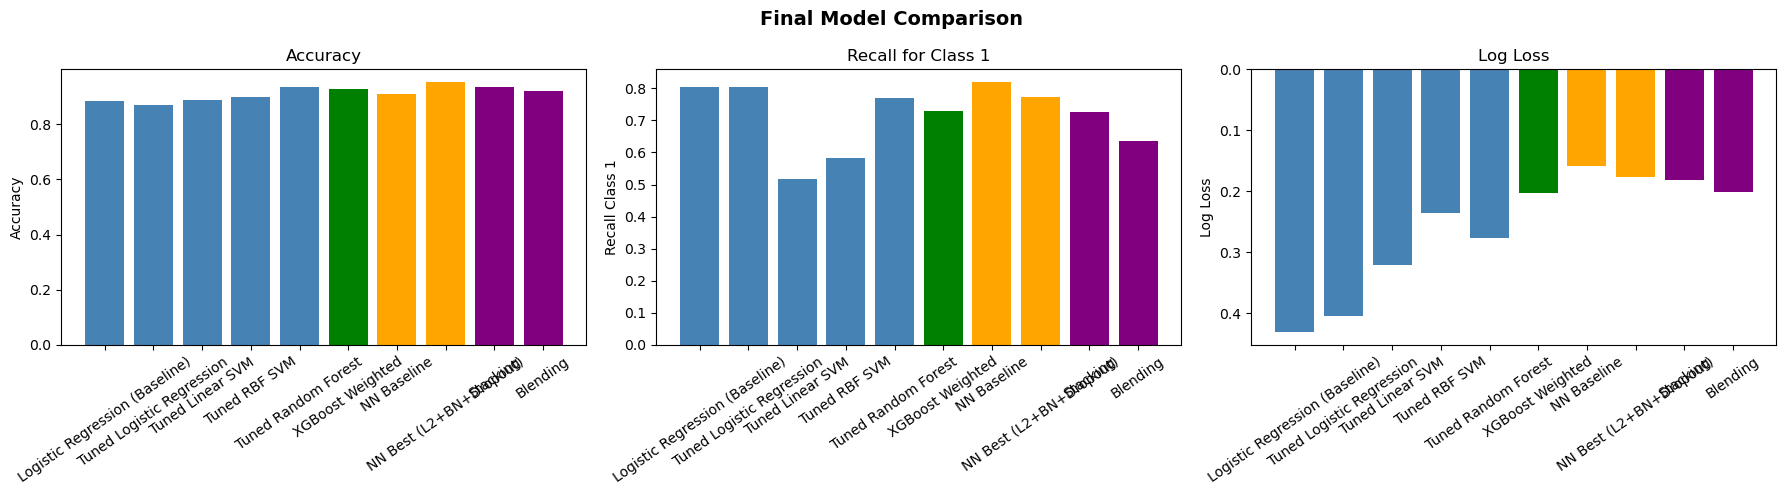

In [22]:
# Prepare data (drop rows with missing values if any)
plot_df = results_df.dropna(subset=["Accuracy", "Recall Class 1", "Log Loss"]).copy()

# Define color map
color_map = {
    "Traditional ML": "steelblue",
    "Boosting": "green",
    "Deep Learning": "orange",
    "Ensemble": "purple"
}

# Generate color list based on model type
colors = [color_map[t] for t in plot_df["Model Type"]]

# Create plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Accuracy", "Recall Class 1", "Log Loss"]
titles = ["Accuracy", "Recall for Class 1", "Log Loss"]

for ax, metric, title in zip(axes, metrics, titles):
    ax.bar(plot_df["Model"], plot_df[metric], color=colors)
    ax.set_title(title)
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=35)

    if metric == "Log Loss":
        ax.invert_yaxis()

plt.suptitle("Final Model Comparison", fontsize=14, fontweight="bold")
plt.tight_layout()

# Save figure for report
plt.savefig(REPORTS_DIR / "final_model_comparison_bar_chart.png", dpi=300, bbox_inches="tight")

plt.show()

## Final Summary

This project compared traditional machine learning, boosting, deep learning, and ensemble methods for predicting age-related medical conditions.

The results show that no single model was best across all metrics. The regularized neural network achieved the highest overall accuracy, while the baseline neural network produced the lowest log loss, indicating strong probability calibration. XGBoost remained a competitive model, particularly after addressing class imbalance, and provided valuable interpretability through feature importance analysis.

Traditional machine learning models, especially Random Forest, performed well and served as strong baselines. However, methods such as Support Vector Machines showed limitations in handling class imbalance, particularly in recall for Class 1.

Ensemble methods, including stacking and blending, did not significantly outperform the best individual models. This suggests that the base models captured similar patterns, limiting the benefit of combining them.

Overall, the results demonstrate that boosting and deep learning methods are highly effective for structured biomedical data, while also highlighting the importance of selecting appropriate evaluation metrics. In this context, improving recall for Class 1 and optimizing log loss were more meaningful than maximizing accuracy alone.

These findings emphasize the importance of model selection, proper handling of class imbalance, and careful evaluation when working with real-world classification problems in healthcare.